## **PAIR ASSIGNMENT**

Please work in pairs for this exercise. Pair up with the person next to you. If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand, and I will assist in pairing you with someone.


### **Task 0: Please assign your full name and your partner's full name to the variables below, respectively.**


Example:

```
your_name = 'Taylor Swift'
your_partner_name = 'Travis Kelce'
```

In [ ]:
# Assign your and your partner's names here.  If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand.
# If, in the end, we are unable to find a partner for you, please assign the word "self" to the `your_partner_name` variable.
your_name = 'Jonathan Cruz'
your_partner_name = ''

# **Probability Distributions and Bayesian Inference**

In this notebook exercise, we will explore fundamental probability concepts that are essential for data science and machine learning. Understanding probability distributions and how to work with them is crucial for statistical modeling, hypothesis testing, and building probabilistic models.

## **Why Probability Matters in Data Science**

- **Uncertainty Quantification**: Real-world data is inherently noisy and uncertain. Probability provides a framework for reasoning about uncertainty.
- **Statistical Inference**: Drawing conclusions about populations from samples requires understanding probability distributions.
- **Machine Learning**: Many ML algorithms are based on probabilistic models (Naive Bayes, Gaussian Mixture Models, etc.).
- **Decision Making**: Probability helps us make optimal decisions under uncertainty.

## **Key Concepts We'll Cover**

1. **Probability Distributions**: Mathematical functions that describe the likelihood of different outcomes
   - **Discrete distributions**: Outcomes are countable (e.g., Bernoulli, Poisson)
   - **Continuous distributions**: Outcomes can take any value in a range (e.g., Normal/Gaussian)

2. **Conditional Probability**: The probability of an event given that another event has occurred
   - $P(A|B) = \frac{P(A \cap B)}{P(B)}$

3. **Bayes' Rule**: A way to update our beliefs based on new evidence
   - $P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$

4. **Distribution Fitting**: Estimating distribution parameters from observed data

## **Objectives**

In this exercise, you will:
1. Sample from continuous (Normal) and discrete (Bernoulli) distributions using scipy
2. Calculate conditional probabilities from given information
3. Apply Bayes' rule to update probability estimates with new evidence
4. Fit a Normal distribution to data and compute/plot the cumulative distribution function (CDF)
5. Fit a Poisson distribution to traffic count data using scipy.stats.fit

## **Import Libraries**

Let's start by importing the necessary libraries for our analysis.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

## **TASK 1: Sampling from Probability Distributions**

Scipy's `stats` module provides many probability distributions. Each distribution object has methods like:
- `rvs()`: Generate random samples (Random Variates)
- `pdf()` / `pmf()`: Probability density/mass function
- `cdf()`: Cumulative distribution function
- `mean()`, `var()`, `std()`: Distribution statistics

### **Part A: Normal (Gaussian) Distribution - Continuous**

The Normal distribution is the most important continuous distribution in statistics. It's characterized by:
- **Mean ($\mu$)**: The center of the distribution
- **Standard deviation ($\sigma$)**: The spread of the distribution

The probability density function (PDF) is:
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

Generate 1000 samples from a Normal distribution with mean=100 and standard deviation=15 (like IQ scores).

In [24]:
# Write your code here
from scipy.stats import norm

# Define the parameters
mu = 100      # Mean
sigma = 15    # Standard deviation
n_samples = 1000

# Create a Normal distribution object
normal_dist = norm(loc=mu, scale=sigma)

# Generate random samples
normal_samples = normal_dist.rvs(size=n_samples)

print("Normal Distribution Sampling")
print("=" * 50)
print(f"Parameters: mu = {mu}, sigma = {sigma}")
print(f"Number of samples: {n_samples}")
print(f"\nSample statistics:")
print(f"  Sample mean: {np.mean(normal_samples):.2f} (theoretical: {mu})")
print(f"  Sample std:  {np.std(normal_samples, ddof=1):.2f} (theoretical: {sigma})")
print(f"  Min value:   {np.min(normal_samples):.2f}")
print(f"  Max value:   {np.max(normal_samples):.2f}")

# Display first 10 samples
print(f"\nFirst 10 samples: {normal_samples[:10].round(2)}")

Normal Distribution Sampling
Parameters: mu = 100, sigma = 15
Number of samples: 1000

Sample statistics:
  Sample mean: 101.48 (theoretical: 100)
  Sample std:  14.83 (theoretical: 15)
  Min value:   56.18
  Max value:   147.90

First 10 samples: [102.67  79.97 105.7  109.16 108.4  116.21 112.51 106.89  98.95  75.09]


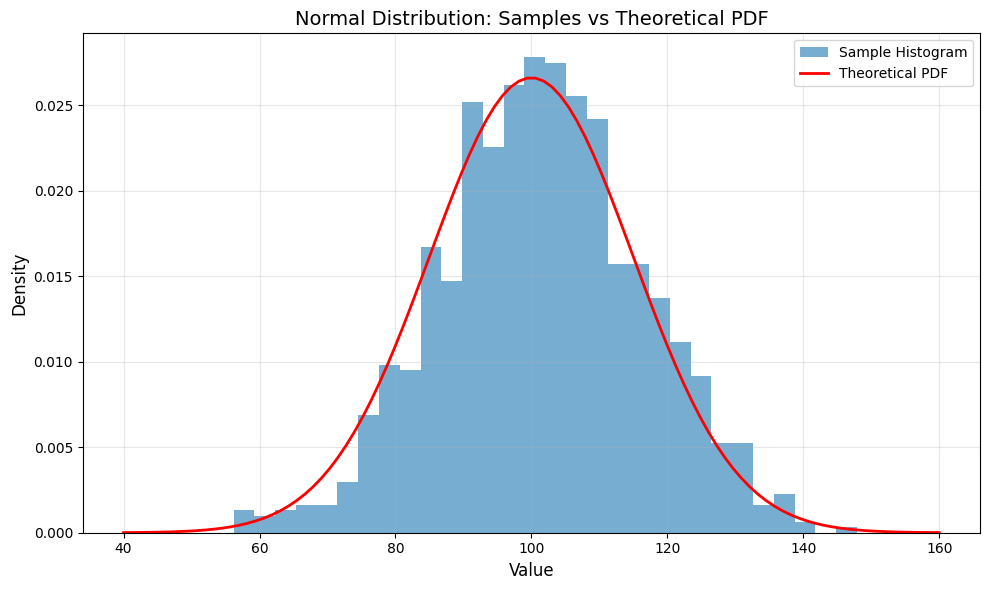

In [25]:
# Visualize the samples with a histogram and overlay the theoretical PDF
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram of samples
ax.hist(normal_samples, bins=30, density=True, alpha=0.6, label="Sample Histogram")

# Theoretical PDF
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
ax.plot(x, normal_dist.pdf(x), 'r-', linewidth=2, label='Theoretical PDF')

ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Normal Distribution: Samples vs Theoretical PDF', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Part B: Bernoulli Distribution - Discrete**

The Bernoulli distribution models a single trial with two outcomes (success/failure). It's characterized by:
- **p**: Probability of success (1)
- **1-p**: Probability of failure (0)

The probability mass function (PMF) is:
$$P(X = k) = p^k (1-p)^{1-k} \text{ for } k \in \{0, 1\}$$

Generate 1000 samples from a Bernoulli distribution with p=0.3 (like coin flips with a biased coin).

In [26]:
# Define the parameter
p = 0.3  # Probability of success
n_samples = 1000

# Write your code here
from scipy.stats import bernoulli

# Create a Bernoulli distribution object
bernoulli_dist = bernoulli(p)

# Generate random samples
bernoulli_samples = bernoulli_samples = bernoulli_dist.rvs(size=n_samples)

print("Bernoulli Distribution Sampling")
print("=" * 50)
print(f"Parameter: p = {p}")
print(f"Number of samples: {n_samples}")

# Count successes and failures
n_successes = np.sum(bernoulli_samples)
n_failures = n_samples - n_successes

print(f"\nResults:")
print(f"  Successes (1): {n_successes} ({n_successes/n_samples:.1%})")
print(f"  Failures (0):  {n_failures} ({n_failures/n_samples:.1%})")
print(f"\nSample mean: {np.mean(bernoulli_samples):.3f} (theoretical: {p})")
print(f"Sample variance: {np.var(bernoulli_samples, ddof=1):.3f} (theoretical: {p*(1-p):.3f})")

# Display first 20 samples
print(f"\nFirst 20 samples: {bernoulli_samples[:20]}")

Bernoulli Distribution Sampling
Parameter: p = 0.3
Number of samples: 1000

Results:
  Successes (1): 294 (29.4%)
  Failures (0):  706 (70.6%)

Sample mean: 0.294 (theoretical: 0.3)
Sample variance: 0.208 (theoretical: 0.210)

First 20 samples: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0]


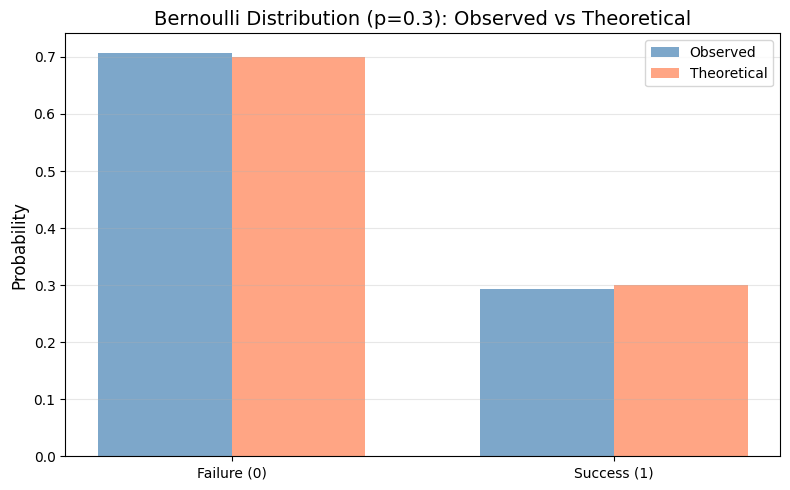

In [27]:
# Visualize with a bar chart
fig, ax = plt.subplots(figsize=(8, 5))

# Count values
unique, counts = np.unique(bernoulli_samples, return_counts=True)
observed_probs = counts / n_samples

# Bar positions
bar_width = 0.35
x_pos = np.array([0, 1])

# Plot observed vs theoretical
ax.bar(x_pos - bar_width/2, observed_probs, bar_width, alpha=0.7, 
       color='steelblue', label='Observed')
ax.bar(x_pos + bar_width/2, [1-p, p], bar_width, alpha=0.7, 
       color='coral', label='Theoretical')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Failure (0)', 'Success (1)'])
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(f'Bernoulli Distribution (p={p}): Observed vs Theoretical', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## **TASK 2: Conditional Probability**

**Conditional probability** is the probability of an event occurring given that another event has already occurred.

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

Where:
- $P(A|B)$ is the probability of A given B
- $P(A \cap B)$ is the probability of both A and B occurring (intersection)
- $P(B)$ is the probability of B

### **Example Problem: Student Performance**

In a class of students:
- 60% of students study regularly (event S)
- 70% of students pass the exam (event P)
- 50% of students both study regularly AND pass the exam (intersection S ∩ P)

Calculate:
1. The probability that a student passes the exam given that they study regularly: $P(P|S)$
2. The probability that a student studies regularly given that they passed: $P(S|P)$

In [28]:
# Given probabilities
P_S = 0.60        # P(Study regularly)
P_P = 0.70        # P(Pass exam)
P_S_and_P = 0.50  # P(Study AND Pass)

print("Conditional Probability Calculations")
print("=" * 50)
print(f"\nGiven information:")
print(f"  P(Study) = {P_S:.2f}")
print(f"  P(Pass) = {P_P:.2f}")
print(f"  P(Study AND Pass) = {P_S_and_P:.2f}")

# Calculate conditional probabilities
# P(Pass | Study) = P(Study AND Pass) / P(Study)
P_P_given_S = P_S_and_P / P_S

# P(Study | Pass) = P(Study AND Pass) / P(Pass)
P_S_given_P = P_S_and_P / P_P

print(f"\nConditional Probabilities:")
print(f"  P(Pass | Study) = {P_S_and_P} / {P_S} = {P_P_given_S:.4f}")
print(f"  P(Study | Pass) = {P_S_and_P} / {P_P} = {P_S_given_P:.4f}")

print(f"\nInterpretation:")
print(f"  - {P_P_given_S:.1%} of students who study regularly pass the exam")
print(f"  - {P_S_given_P:.1%} of students who passed studied regularly")

Conditional Probability Calculations

Given information:
  P(Study) = 0.60
  P(Pass) = 0.70
  P(Study AND Pass) = 0.50

Conditional Probabilities:
  P(Pass | Study) = 0.5 / 0.6 = 0.8333
  P(Study | Pass) = 0.5 / 0.7 = 0.7143

Interpretation:
  - 83.3% of students who study regularly pass the exam
  - 71.4% of students who passed studied regularly


## **TASK 3: Bayes' Rule and Updating Probabilities**

**Bayes' Rule** allows us to update our belief about an event based on new evidence:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Or more commonly written as:

$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$$

Where:
- $P(H)$ is the **prior probability** - our initial belief about hypothesis H
- $P(E|H)$ is the **likelihood** - probability of seeing evidence E if H is true
- $P(E)$ is the **marginal likelihood** - total probability of evidence E
- $P(H|E)$ is the **posterior probability** - our updated belief after seeing evidence

### **Example Problem: Medical Testing**

A rare disease affects 1% of the population. A diagnostic test has:
- 95% sensitivity (true positive rate): If you have the disease, the test is positive 95% of the time
- 90% specificity (true negative rate): If you don't have the disease, the test is negative 90% of the time

If a patient tests positive, what is the probability they actually have the disease?

In [29]:
# Write your code here

# Given probabilities
P_disease = 0.01                    # Prior: P(Disease)
P_no_disease = 1 - P_disease        # P(No Disease)

sensitivity = 0.95                  # P(Positive | Disease) - true positive rate
specificity = 0.90                  # P(Negative | No Disease) - true negative rate

# Derived probabilities
P_pos_given_disease = sensitivity   # P(+|D)
P_neg_given_no_disease = specificity # P(-|~D)
P_pos_given_no_disease = 1 - specificity  # False positive rate: P(+|~D)

print("Bayes' Rule: Medical Testing Example")
print("=" * 50)
print(f"\nGiven information:")
print(f"  Prior P(Disease) = {P_disease:.2%}")
print(f"  Sensitivity P(+|Disease) = {sensitivity:.2%}")
print(f"  Specificity P(-|No Disease) = {specificity:.2%}")
print(f"  False Positive Rate P(+|No Disease) = {P_pos_given_no_disease:.2%}")

Bayes' Rule: Medical Testing Example

Given information:
  Prior P(Disease) = 1.00%
  Sensitivity P(+|Disease) = 95.00%
  Specificity P(-|No Disease) = 90.00%
  False Positive Rate P(+|No Disease) = 10.00%


In [30]:
# Calculate P(Positive) using the law of total probability
# P(+) = P(+|D)P(D) + P(+|~D)P(~D)
P_positive = (P_pos_given_disease * P_disease) + (P_pos_given_no_disease * P_no_disease)

print(f"\nStep 1: Calculate P(Positive) using Law of Total Probability")
print(f"  P(+) = P(+|D)P(D) + P(+|~D)P(~D)")
print(f"  P(+) = ({P_pos_given_disease})({P_disease}) + ({P_pos_given_no_disease})({P_no_disease})")
print(f"  P(+) = {P_pos_given_disease * P_disease:.4f} + {P_pos_given_no_disease * P_no_disease:.4f}")
print(f"  P(+) = {P_positive:.4f}")


Step 1: Calculate P(Positive) using Law of Total Probability
  P(+) = P(+|D)P(D) + P(+|~D)P(~D)
  P(+) = (0.95)(0.01) + (0.09999999999999998)(0.99)
  P(+) = 0.0095 + 0.0990
  P(+) = 0.1085


In [31]:
# Apply Bayes' Rule
# P(D|+) = P(+|D) * P(D) / P(+)
P_disease_given_positive = (P_pos_given_disease * P_disease) / P_positive
print(f"\nStep 2: Apply Bayes' Rule")
print(f"  P(D|+) = P(+|D) * P(D) / P(+)")
print(f"  P(D|+) = ({P_pos_given_disease}) * ({P_disease}) / ({P_positive:.4f})")
print(f"  P(D|+) = {P_disease_given_positive:.4f}")

print(f"\n" + "=" * 50)
print(f"RESULT: If a patient tests positive, there is a {P_disease_given_positive:.1%}")
print(f"probability they actually have the disease.")
print(f"\nThis surprisingly low probability (despite a 95% accurate test) is")
print(f"because the disease is rare - most positive tests are false positives!")


Step 2: Apply Bayes' Rule
  P(D|+) = P(+|D) * P(D) / P(+)
  P(D|+) = (0.95) * (0.01) / (0.1085)
  P(D|+) = 0.0876

RESULT: If a patient tests positive, there is a 8.8%
probability they actually have the disease.

This surprisingly low probability (despite a 95% accurate test) is
because the disease is rare - most positive tests are false positives!


In [32]:
# Visualize the breakdown for 10,000 people
n_people = 10000

# Calculate expected numbers
n_with_disease = int(n_people * P_disease)
n_without_disease = n_people - n_with_disease

n_true_positive = int(n_with_disease * P_pos_given_disease)
n_false_negative = n_with_disease - n_true_positive
n_false_positive = int(n_without_disease * P_pos_given_no_disease)
n_true_negative = n_without_disease - n_false_positive

print(f"\nVisualization: Testing {n_people:,} People")
print("=" * 50)
print(f"\nPeople WITH the disease: {n_with_disease}")
print(f"  - True Positives (correctly identified): {n_true_positive}")
print(f"  - False Negatives (missed): {n_false_negative}")
print(f"\nPeople WITHOUT the disease: {n_without_disease}")
print(f"  - True Negatives (correctly identified): {n_true_negative}")
print(f"  - False Positives (wrongly flagged): {n_false_positive}")
print(f"\nTotal Positive Tests: {n_true_positive + n_false_positive}")
print(f"  - Of which actually have disease: {n_true_positive} ({n_true_positive/(n_true_positive + n_false_positive):.1%})")


Visualization: Testing 10,000 People

People WITH the disease: 100
  - True Positives (correctly identified): 95
  - False Negatives (missed): 5

People WITHOUT the disease: 9900
  - True Negatives (correctly identified): 8911
  - False Positives (wrongly flagged): 989

Total Positive Tests: 1084
  - Of which actually have disease: 95 (8.8%)


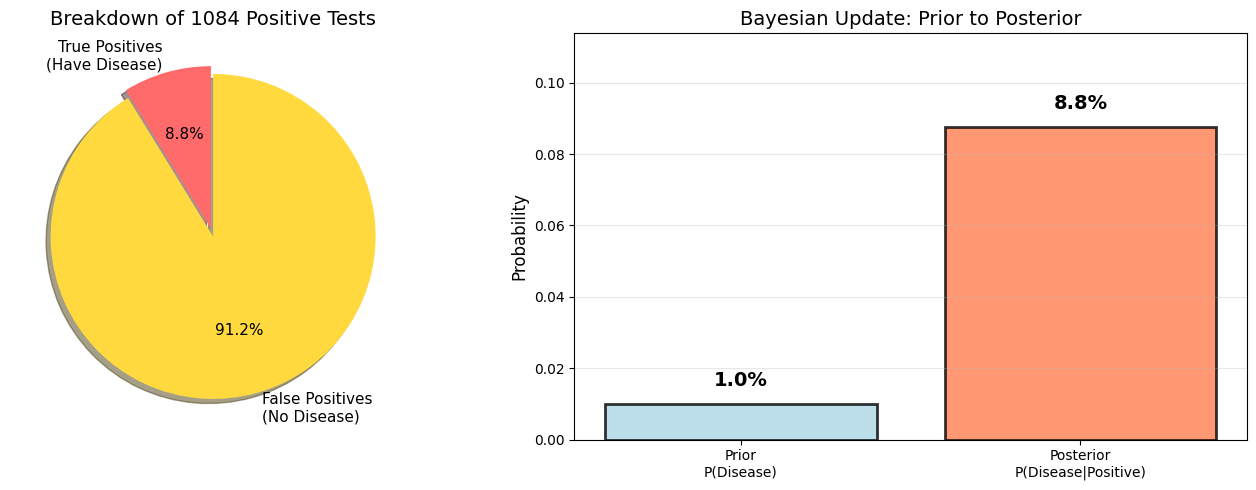

In [33]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Breakdown of positive tests
ax1 = axes[0]
labels = ['True Positives\n(Have Disease)', 'False Positives\n(No Disease)']
sizes = [n_true_positive, n_false_positive]
colors = ['#ff6b6b', '#ffd93d']
explode = (0.05, 0)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 11})
ax1.set_title(f'Breakdown of {n_true_positive + n_false_positive} Positive Tests', fontsize=14)

# Right plot: Prior vs Posterior
ax2 = axes[1]
categories = ['Prior\nP(Disease)', 'Posterior\nP(Disease|Positive)']
probabilities = [P_disease, P_disease_given_positive]
colors = ['lightblue', 'coral']

bars = ax2.bar(categories, probabilities, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

for bar, prob in zip(bars, probabilities):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{prob:.1%}', ha='center', fontsize=14, fontweight='bold')

ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Bayesian Update: Prior to Posterior', fontsize=14)
ax2.set_ylim(0, max(probabilities) * 1.3)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## **TASK 4: Fitting a Normal Distribution and Computing the CDF**

Given observed data, we often want to:
1. **Fit a distribution** - Estimate the parameters that best describe the data
2. **Compute the CDF** - The Cumulative Distribution Function tells us P(X ≤ x)

The CDF is useful for answering questions like:
- What percentage of values fall below a certain threshold?
- What value corresponds to a given percentile?

### **Example: Student Test Scores**

We have test scores from 500 students. Let's fit a Normal distribution and analyze the results.

In [34]:
# Generate synthetic test score data (simulating real student scores)
np.random.seed(42)

# True parameters (unknown in real scenarios)
true_mean = 72
true_std = 12

# Generate 500 test scores
n_students = 500
test_scores = np.random.normal(true_mean, true_std, n_students)

# Clip to realistic range [0, 100]
test_scores = np.clip(test_scores, 0, 100)

print("Student Test Score Data")
print("=" * 50)
print(f"Number of students: {n_students}")
print(f"\nDescriptive Statistics:")
print(f"  Mean:   {np.mean(test_scores):.2f}")
print(f"  Std:    {np.std(test_scores, ddof=1):.2f}")
print(f"  Median: {np.median(test_scores):.2f}")
print(f"  Min:    {np.min(test_scores):.2f}")
print(f"  Max:    {np.max(test_scores):.2f}")

Student Test Score Data
Number of students: 500

Descriptive Statistics:
  Mean:   72.02
  Std:    11.58
  Median: 72.15
  Min:    33.10
  Max:    100.00


In [35]:
# Write your code here

# Fit a Normal distribution to the data using Maximum Likelihood Estimation
# stats.norm.fit() returns (mu, sigma) estimates
fitted_mu, fitted_sigma = ...

print("\nFitting Normal Distribution to Test Scores")
print("=" * 50)
print(f"\nEstimated parameters (Maximum Likelihood):")
print(f"  Mean (mu):     {fitted_mu:.2f}")
print(f"  Std (sigma):   {fitted_sigma:.2f}")
print(f"\nTrue parameters (for comparison):")
print(f"  True mean:     {true_mean}")
print(f"  True std:      {true_std}")

# Create the fitted distribution object
fitted_dist = stats.norm(loc=fitted_mu, scale=fitted_sigma)

TypeError: cannot unpack non-iterable ellipsis object

In [36]:
# Compute and analyze the CDF
print("\nCDF Analysis: Probability of Scoring Below Certain Thresholds")
print("=" * 60)

# Common grade thresholds
thresholds = [60, 70, 80, 90]

for threshold in thresholds:
    # CDF gives P(X <= threshold).  Use fitted_dist.cdf(...)
    prob_below = ...
    prob_above = 1 - prob_below
    
    print(f"\nScore threshold: {threshold}")
    print(f"  P(Score <= {threshold}) = {prob_below:.4f} ({prob_below:.1%})")
    print(f"  P(Score > {threshold})  = {prob_above:.4f} ({prob_above:.1%})")


CDF Analysis: Probability of Scoring Below Certain Thresholds


TypeError: unsupported operand type(s) for -: 'int' and 'ellipsis'

In [37]:
# Find percentiles using the inverse CDF (ppf = percent point function)
print("\nPercentile Analysis: Score at Various Percentiles")
print("=" * 50)

percentiles = [10, 25, 50, 75, 90, 95]

for p in percentiles:
    score_at_percentile = fitted_dist.ppf(p / 100)
    print(f"  {p}th percentile: Score = {score_at_percentile:.2f}")


Percentile Analysis: Score at Various Percentiles


NameError: name 'fitted_dist' is not defined

NameError: name 'fitted_dist' is not defined

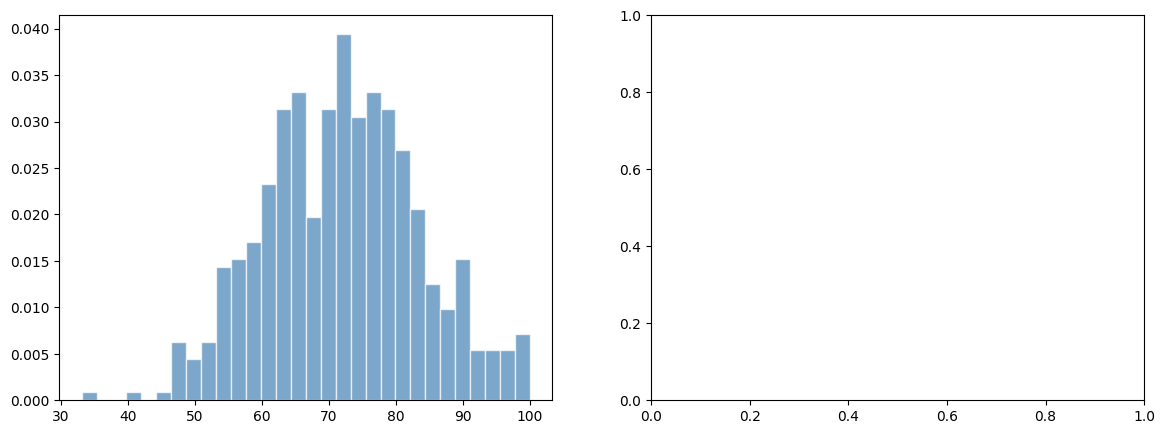

In [38]:
# Visualize the fitted distribution and CDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Histogram with fitted PDF
ax1 = axes[0]
x = np.linspace(test_scores.min() - 10, test_scores.max() + 10, 200)

ax1.hist(test_scores, bins=30, density=True, alpha=0.7, color='steelblue', 
         edgecolor='white', label='Observed data')
ax1.plot(x, fitted_dist.pdf(x), 'r-', linewidth=2, 
         label=f'Fitted Normal\n(μ={fitted_mu:.1f}, σ={fitted_sigma:.1f})')

ax1.set_xlabel('Test Score', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Test Scores: Data and Fitted Normal Distribution', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: CDF
ax2 = axes[1]

# Empirical CDF (from data)
sorted_scores = np.sort(test_scores)
empirical_cdf = np.arange(1, n_students + 1) / n_students
ax2.step(sorted_scores, empirical_cdf, where='post', alpha=0.7, 
         color='steelblue', linewidth=1.5, label='Empirical CDF')

# Theoretical CDF (from fitted distribution)
ax2.plot(x, fitted_dist.cdf(x), 'r-', linewidth=2, label='Fitted Normal CDF')

ax2.set_xlabel('Test Score', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('Cumulative Distribution Function (CDF)', fontsize=14)
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(30, 110)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## **TASK 5: Fitting a Poisson Distribution to Traffic Data**

The **Poisson distribution** models the number of events occurring in a fixed interval of time or space. It's characterized by:
- **λ (lambda)**: The average rate of events

The probability mass function is:
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

Common applications:
- Number of cars passing a checkpoint per hour
- Number of customer arrivals per minute
- Number of defects per product

### **Example: Traffic Count Data**

We have data on the number of cars passing a traffic counter every 5-minute interval over several hours. Let's fit a Poisson distribution using `scipy.stats.fit()`.

In [39]:
# Generate synthetic traffic count data
np.random.seed(123)

# True lambda (average cars per 5-minute interval)
true_lambda = 8

# Generate 200 observations (about 16 hours of data)
n_intervals = 200
traffic_counts = np.random.poisson(true_lambda, n_intervals)

print("Traffic Count Data (Cars per 5-minute interval)")
print("=" * 50)
print(f"Number of 5-minute intervals observed: {n_intervals}")
print(f"\nDescriptive Statistics:")
print(f"  Mean:   {np.mean(traffic_counts):.2f} cars")
print(f"  Var:    {np.var(traffic_counts, ddof=1):.2f}")
print(f"  Min:    {np.min(traffic_counts)} cars")
print(f"  Max:    {np.max(traffic_counts)} cars")

print(f"\nNote: For a Poisson distribution, mean ≈ variance")
print(f"  Mean/Variance ratio: {np.mean(traffic_counts)/np.var(traffic_counts, ddof=1):.3f}")

# Display value counts
print(f"\nFrequency distribution:")
unique, counts = np.unique(traffic_counts, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u:2d} cars: {c:3d} intervals ({c/n_intervals:5.1%})")

Traffic Count Data (Cars per 5-minute interval)
Number of 5-minute intervals observed: 200

Descriptive Statistics:
  Mean:   7.83 cars
  Var:    8.65
  Min:    2 cars
  Max:    16 cars

Note: For a Poisson distribution, mean ≈ variance
  Mean/Variance ratio: 0.905

Frequency distribution:
   2 cars:   4 intervals ( 2.0%)
   3 cars:  10 intervals ( 5.0%)
   4 cars:  11 intervals ( 5.5%)
   5 cars:  18 intervals ( 9.0%)
   6 cars:  28 intervals (14.0%)
   7 cars:  24 intervals (12.0%)
   8 cars:  27 intervals (13.5%)
   9 cars:  23 intervals (11.5%)
  10 cars:  19 intervals ( 9.5%)
  11 cars:  14 intervals ( 7.0%)
  12 cars:   8 intervals ( 4.0%)
  13 cars:   7 intervals ( 3.5%)
  14 cars:   2 intervals ( 1.0%)
  15 cars:   4 intervals ( 2.0%)
  16 cars:   1 intervals ( 0.5%)


In [40]:
# Write your code here

# Use scipy.stats.fit() to fit a Poisson distribution
# Note: stats.fit() is a general fitting function that uses MLE
# For Poisson, the MLE estimate of lambda is simply the sample mean

# Method 1: Using stats.fit() (available in scipy >= 1.9)
# This returns a FitResult object with various attributes
fit_result = ...

print("\nFitting Poisson Distribution using scipy.stats.fit()")
print("=" * 50)
print(f"\nFit Result:")
print(f"  Estimated lambda (mu): {fit_result.params.mu:.4f}")
print(f"  True lambda:           {true_lambda}")
print(f"\nFor comparison, sample mean: {np.mean(traffic_counts):.4f}")
print(f"(MLE for Poisson lambda equals the sample mean)")


Fitting Poisson Distribution using scipy.stats.fit()

Fit Result:


AttributeError: 'ellipsis' object has no attribute 'params'

In [41]:
# Method 2: Direct MLE (for Poisson, lambda_hat = sample mean)
lambda_mle = np.mean(traffic_counts)

# Create the fitted distribution
fitted_poisson = stats.poisson(mu=lambda_mle)

print(f"\nFitted Poisson Distribution Analysis")
print("=" * 50)
print(f"\nExpected probabilities from fitted distribution:")

for k in range(0, 20):
    prob = fitted_poisson.pmf(k)
    expected_count = prob * n_intervals
    observed_count = np.sum(traffic_counts == k)
    if prob > 0.001:  # Only show non-negligible probabilities
        print(f"  P(X={k:2d}) = {prob:.4f}  Expected: {expected_count:5.1f}  Observed: {observed_count:3d}")


Fitted Poisson Distribution Analysis

Expected probabilities from fitted distribution:
  P(X= 1) = 0.0031  Expected:   0.6  Observed:   0
  P(X= 2) = 0.0122  Expected:   2.4  Observed:   4
  P(X= 3) = 0.0318  Expected:   6.4  Observed:  10
  P(X= 4) = 0.0623  Expected:  12.5  Observed:  11
  P(X= 5) = 0.0975  Expected:  19.5  Observed:  18
  P(X= 6) = 0.1273  Expected:  25.5  Observed:  28
  P(X= 7) = 0.1424  Expected:  28.5  Observed:  24
  P(X= 8) = 0.1393  Expected:  27.9  Observed:  27
  P(X= 9) = 0.1212  Expected:  24.2  Observed:  23
  P(X=10) = 0.0949  Expected:  19.0  Observed:  19
  P(X=11) = 0.0676  Expected:  13.5  Observed:  14
  P(X=12) = 0.0441  Expected:   8.8  Observed:   8
  P(X=13) = 0.0266  Expected:   5.3  Observed:   7
  P(X=14) = 0.0149  Expected:   3.0  Observed:   2
  P(X=15) = 0.0078  Expected:   1.6  Observed:   4
  P(X=16) = 0.0038  Expected:   0.8  Observed:   1
  P(X=17) = 0.0017  Expected:   0.3  Observed:   0


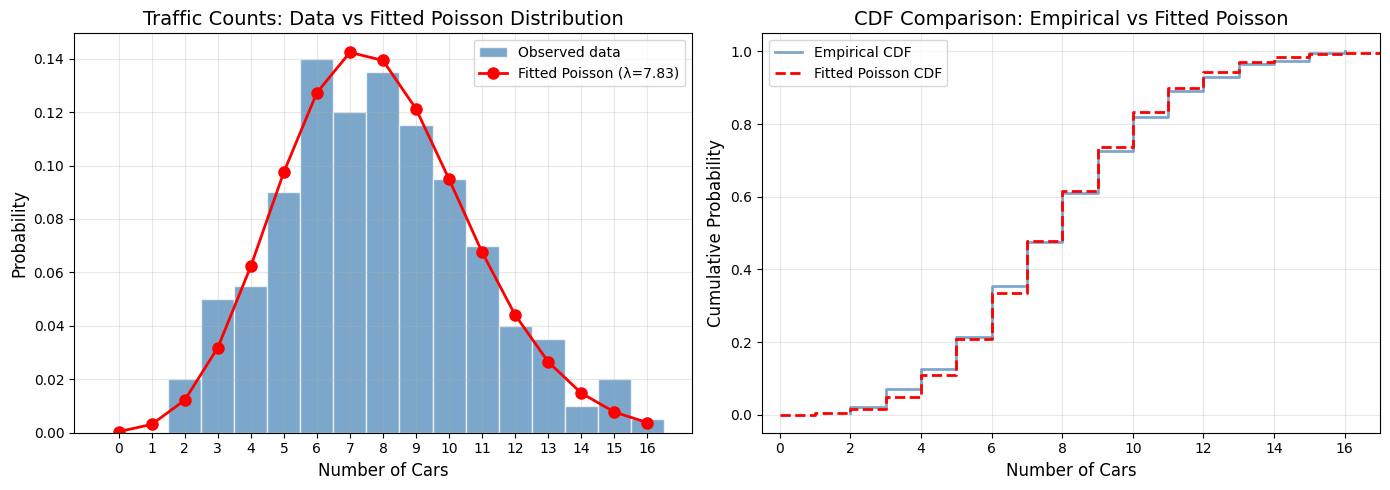

In [42]:
# Visualize the fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Histogram with fitted PMF
ax1 = axes[0]

# Observed data histogram
max_count = traffic_counts.max()
bins = np.arange(-0.5, max_count + 1.5, 1)
ax1.hist(traffic_counts, bins=bins, density=True, alpha=0.7, color='steelblue',
         edgecolor='white', label='Observed data')

# Fitted PMF
k_values = np.arange(0, max_count + 1)
pmf_values = fitted_poisson.pmf(k_values)
ax1.plot(k_values, pmf_values, 'ro-', markersize=8, linewidth=2,
         label=f'Fitted Poisson (λ={lambda_mle:.2f})')

ax1.set_xlabel('Number of Cars', fontsize=12)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title('Traffic Counts: Data vs Fitted Poisson Distribution', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_values)

# Right plot: CDF comparison
ax2 = axes[1]

# Empirical CDF
sorted_counts = np.sort(traffic_counts)
empirical_cdf = np.arange(1, n_intervals + 1) / n_intervals
ax2.step(sorted_counts, empirical_cdf, where='post', alpha=0.7,
         color='steelblue', linewidth=2, label='Empirical CDF')

# Theoretical CDF
k_fine = np.arange(0, max_count + 2)
theoretical_cdf = fitted_poisson.cdf(k_fine)
ax2.step(k_fine, theoretical_cdf, where='post', color='red', 
         linewidth=2, linestyle='--', label='Fitted Poisson CDF')

ax2.set_xlabel('Number of Cars', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('CDF Comparison: Empirical vs Fitted Poisson', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.5, max_count + 1)

plt.tight_layout()
plt.show()

In [43]:
# Practical applications of the fitted distribution
print("\nPractical Applications of the Fitted Poisson Model")
print("=" * 50)

# What's the probability of seeing more than 12 cars in a 5-minute interval?
prob_gt_12 = 1 - fitted_poisson.cdf(12)
print(f"\n1. P(More than 12 cars) = {prob_gt_12:.4f} ({prob_gt_12:.2%})")

# What's the probability of seeing exactly 8 cars?
prob_exactly_8 = fitted_poisson.pmf(8)
print(f"\n2. P(Exactly 8 cars) = {prob_exactly_8:.4f} ({prob_exactly_8:.2%})")

# What's the probability of seeing fewer than 5 cars (light traffic)?
prob_lt_5 = fitted_poisson.cdf(4)
print(f"\n3. P(Fewer than 5 cars - light traffic) = {prob_lt_5:.4f} ({prob_lt_5:.2%})")

# 95th percentile - what count is exceeded only 5% of the time?
percentile_95 = fitted_poisson.ppf(0.95)
print(f"\n4. 95th percentile: {percentile_95:.0f} cars")
print(f"   (Only 5% of intervals see more than {percentile_95:.0f} cars)")


Practical Applications of the Fitted Poisson Model

1. P(More than 12 cars) = 0.0560 (5.60%)

2. P(Exactly 8 cars) = 0.1393 (13.93%)

3. P(Fewer than 5 cars - light traffic) = 0.1098 (10.98%)

4. 95th percentile: 13 cars
   (Only 5% of intervals see more than 13 cars)


## **Summary and Key Takeaways**

### What we learned:

1. **Probability Distributions**:
   - **Continuous distributions** (like Normal) have probability density functions (PDF)
   - **Discrete distributions** (like Bernoulli, Poisson) have probability mass functions (PMF)
   - Use `scipy.stats` to create, sample from, and analyze distributions

2. **Sampling from Distributions**:
   - `stats.norm(loc=mu, scale=sigma).rvs(size=n)` for Normal samples
   - `stats.bernoulli(p=p).rvs(size=n)` for Bernoulli samples
   - `stats.poisson(mu=lambda).rvs(size=n)` for Poisson samples

3. **Conditional Probability**:
   - $P(A|B) = \frac{P(A \cap B)}{P(B)}$
   - Allows us to update probabilities when we have partial information

4. **Bayes' Rule**:
   - $P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$
   - Connects prior beliefs with evidence to produce posterior beliefs
   - The "base rate fallacy" shows why priors matter!

5. **Distribution Fitting**:
   - `stats.norm.fit(data)` estimates parameters via Maximum Likelihood
   - `stats.fit(stats.poisson, data)` provides a general fitting interface
   - Always visualize the fit to assess quality

6. **Cumulative Distribution Function (CDF)**:
   - CDF gives $P(X \leq x)$ - probability of being at or below a value
   - Use `.cdf(x)` to compute probabilities
   - Use `.ppf(p)` (percent point function) to find quantiles/percentiles

### Discussion Questions:

1. Why is the posterior probability in the medical testing example so much lower than the test's 95% accuracy? What does this teach us about interpreting test results?

2. The Poisson distribution assumes events occur independently. When might this assumption be violated for traffic data? What distribution might be more appropriate?

3. How would you decide between using a Normal vs. Poisson distribution to model a dataset? What characteristics of the data would guide your choice?